# Diferenças-em-Diferenças (DiD) — exemplo básico com dados simulados

Este notebook implementa o método de **Diferenças-em-Diferenças** (Difference-in-Differences, DiD), seguindo a mesma lógica do notebook de controle sintético: dados simulados, código comentado, e verificação de que o método recupera um efeito conhecido de antemão.

**Ideia geral do método:** DiD compara a evolução de um grupo que recebeu um tratamento com a evolução de um grupo que não recebeu, entre um período anterior e um posterior ao tratamento. Em vez de olhar só para a diferença entre os grupos depois do tratamento (que pode existir mesmo sem tratamento nenhum, por características prévias dos grupos), ou só para a mudança do grupo tratado ao longo do tempo (que pode ser efeito de qualquer outra coisa que mude com o tempo), DiD combina as duas comparações: a diferença **entre grupos** da diferença **ao longo do tempo**. Isso cancela tanto as diferenças fixas entre os grupos quanto as tendências comuns a ambos, sobrando (sob a suposição abaixo) o efeito do tratamento.

**A suposição central — tendências paralelas:** o método só é válido se, *na ausência do tratamento*, os dois grupos teriam seguido a mesma tendência ao longo do tempo (podendo ter níveis diferentes, mas evoluindo em paralelo). É a mesma lição do notebook de controle sintético — lá, as linhas precisavam ficar coladas no pré-tratamento porque os doadores precisavam compartilhar estrutura real com a unidade tratada; aqui, o grupo de controle precisa compartilhar a mesma tendência do grupo tratado para servir de contrafactual. Por isso, os dados simulados abaixo são construídos com um **componente de tempo comum aos dois grupos**, além de variações individuais próprias de cada unidade. Esse componente comum favorece tendências paralelas *nas médias dos grupos* — não força cada unidade a se mover de forma idêntica (mais detalhes na seção 4). A seção 10 mostra o que acontece quando a suposição é violada de propósito.

Para validar a implementação, injetamos um **efeito de tratamento conhecido** apenas no grupo tratado, só no pós-período — só para fins didáticos, já que em dados simulados dá para conferir se o método recupera um valor que já sabemos de antemão.

**Pesquisa usada como base:** a especificação de regressão, o erro-padrão clusterizado por unidade, e o teste de pré-tendências (event study) seguem a prática padrão descrita em [The Effect (Huntington-Klein)](https://www.theeffectbook.net/ch-DifferenceinDifference.html), [Columbia Public Health](https://www.publichealth.columbia.edu/research/population-health-methods/difference-difference-estimation) e no exemplo de código em Python de [Carlos Mendez](https://carlos-mendez.org/post/python_did/). A ressalva sobre TWFE com adoção escalonada (seção 11) é baseada em [Goodman-Bacon (2021)](https://www.sciencedirect.com/science/article/abs/pii/S0304407620303948) e [Callaway & Sant'Anna](https://pdhp.isr.umich.edu/wp-content/uploads/2023/01/DiD_PDHP.pdf).

## 1. Bibliotecas

`numpy`/`pandas` para os dados, `matplotlib` para os gráficos, e `statsmodels.formula.api` para a regressão de DiD com erro-padrão clusterizado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## 2. Reprodutibilidade

In [2]:
np.random.seed(42)

## 3. Parâmetros do experimento

- `n_control` / `n_treated`: quantas unidades (ex.: lojas, regiões, usuários) tem cada grupo.
- `n_pre` / `n_post`: quantos períodos (meses) antes e depois do início do tratamento.
- `EFFECT_SIZE`: efeito de tratamento conhecido, injetado artificialmente só para validar o método (em um problema real, é o que se quer estimar).

In [3]:
n_control = 40
n_treated = 15
n_pre = 12
n_post = 6
n_total = n_pre + n_post

EFFECT_SIZE = 5.0

## 4. Geração dos dados sintéticos (painel)

Cada unidade (loja, região, o que for) tem duas partes bem diferentes:

- **O que é exclusivo da unidade:** um nível base próprio (`unit_fixed_effect` — unidades diferentes têm patamares diferentes, e tudo bem, DiD não exige que os grupos comecem no mesmo nível), mais um passeio aleatório (`idio_walk`) e ruído (`noise`) próprios. Isso é individual: cada unidade tem o seu, e eles não são compartilhados com mais ninguém.
- **O que é comum a todo mundo:** um **componente de tempo comum** (`common_time_component`) — tendência + sazonalidade + um choque — que entra igual na fórmula de *todas* as unidades, dos dois grupos.

É importante não superinterpretar o papel do componente comum: ele **não** faz cada unidade individual seguir uma trajetória idêntica às demais — cada unidade ainda carrega seu próprio passeio aleatório e ruído, então trajetórias individuais podem variar e até se cruzar. O que o componente comum favorece é mais específico: como ele afeta tratados e controles do mesmo jeito, e as flutuações individuais tendem a se cancelar quando agregamos várias unidades numa média, esperamos que as **médias dos dois grupos** evoluam de forma aproximadamente paralela no pré-período — não que cada unidade, isoladamente, siga exatamente a mesma linha. É essa checagem nas médias de grupo que fazemos visualmente na seção 5.

In [4]:
def common_time_component(n_periods):
    '''Tendência + sazonalidade + choque, compartilhados por todas as unidades.'''
    t = np.arange(n_periods)
    trend = 0.15 * t
    seasonal = 1.2 * np.sin(2 * np.pi * t / 12)
    shock = np.cumsum(np.random.normal(0, 0.1, n_periods))
    return trend + seasonal + shock


def generate_panel(n_control, n_treated, n_total, common):
    records = []
    for group, n_units in [('control', n_control), ('treated', n_treated)]:
        for u in range(n_units):
            unit_id = f'{group}_{u}'
            unit_fixed_effect = np.random.uniform(20, 40)
            idio_walk = np.cumsum(np.random.normal(0, 0.15, n_total))
            noise = np.random.normal(0, 0.5, n_total)
            y = unit_fixed_effect + common + idio_walk + noise
            for t in range(n_total):
                records.append({'unit_id': unit_id, 'group': group, 'time': t, 'y': y[t]})
    return pd.DataFrame(records)

Montamos o painel, adicionamos uma coluna de datas (só para leitura — não afeta o modelo) e injetamos o efeito de tratamento conhecido apenas nas observações do grupo tratado no pós-período.

In [5]:
common = common_time_component(n_total)
df = generate_panel(n_control, n_treated, n_total, common)

df['treated_group'] = (df['group'] == 'treated').astype(int)
df['post_period'] = (df['time'] >= n_pre).astype(int)

dates = pd.date_range(start='2023-01-01', periods=n_total, freq='MS')
df['date'] = df['time'].map(dict(enumerate(dates)))

# Injeta o efeito de tratamento conhecido só no grupo tratado, no pós-período
df.loc[(df['treated_group'] == 1) & (df['post_period'] == 1), 'y'] += EFFECT_SIZE

print(f"Painel com {df['unit_id'].nunique()} unidades x {n_total} períodos = {len(df)} observações")
df.head()

Painel com 55 unidades x 18 períodos = 990 observações


,unit_id,group,time,y,treated_group,post_period,date
0,control_0,control,0,25.154503,0,0,2023-01-01
1,control_0,control,1,26.748289,0,0,2023-02-01
2,control_0,control,2,28.151028,0,0,2023-03-01
3,control_0,control,3,27.911422,0,0,2023-04-01
4,control_0,control,4,27.773659,0,0,2023-05-01


## 5. Tendências paralelas — checagem visual

Antes de qualquer regressão, o primeiro passo em qualquer análise de DiD é **olhar o gráfico**: a média do grupo tratado e a média do grupo de controle devem evoluir em paralelo antes do tratamento (podem estar em níveis diferentes, mas a distância entre elas deve ser estável). É a mesma checagem visual do gráfico de Tratado vs. Controle Sintético no notebook anterior — só que aqui compara médias de grupo em vez de uma unidade tratada vs. uma combinação de doadores.

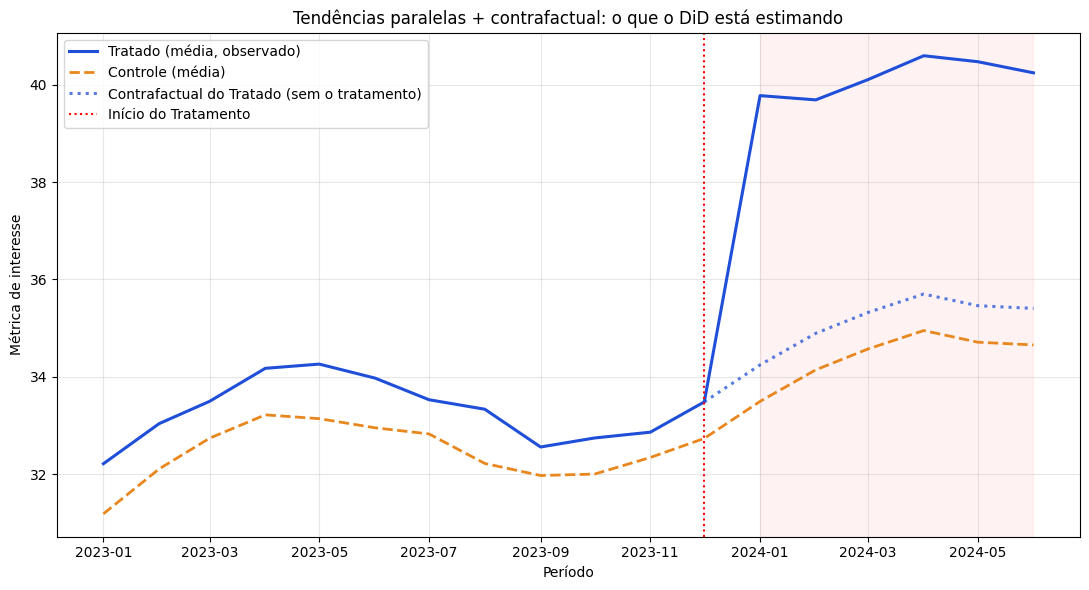

In [6]:
avg_by_group = df.groupby(['date', 'group'])['y'].mean().unstack()
treatment_date = dates[n_pre]

# Contrafactual: "o que teria acontecido com o grupo tratado, se ele NÃO tivesse sido tratado".
# Construção: nível do tratado no fim do pré-período + a MESMA variação que o controle teve
# a partir dali. É a suposição de tendências paralelas escrita como uma linha no gráfico.
treated_pre_end = avg_by_group['treated'].iloc[n_pre - 1]
control_pre_end = avg_by_group['control'].iloc[n_pre - 1]
counterfactual = treated_pre_end + (avg_by_group['control'].iloc[n_pre - 1:] - control_pre_end)

fig, ax = plt.subplots(figsize=(11, 6))
ax.axvspan(treatment_date, dates[-1], color='red', alpha=0.05, zorder=0)
ax.plot(avg_by_group.index, avg_by_group['treated'], label='Tratado (média, observado)', color='#1f4fd8', linewidth=2.2)
ax.plot(avg_by_group.index, avg_by_group['control'], label='Controle (média)', color='#e8871e', linestyle='--', linewidth=2)
ax.plot(counterfactual.index, counterfactual, label='Contrafactual do Tratado (sem o tratamento)', color='#1f4fd8', linestyle=':', linewidth=2.2, alpha=0.75)
ax.axvline(x=dates[n_pre - 1], color='red', linestyle=':', linewidth=1.5, label='Início do Tratamento')
ax.set_title('Tendências paralelas + contrafactual: o que o DiD está estimando')
ax.set_xlabel('Período')
ax.set_ylabel('Métrica de interesse')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

A linha pontilhada azul-clara é o **contrafactual**: a trajetória que o grupo tratado teria seguido *se não tivesse sido tratado*, assumindo tendências paralelas — ou seja, mantendo o nível que o tratado já tinha ao final do pré-período, mas seguindo dali em diante a mesma variação observada no controle. **Esta linha não é estimada diretamente pelo modelo de regressão** (a regressão da seção 7 nunca calcula essa série ponto a ponto): ela é montada à mão, fora da regressão, como uma **representação visual** do contrafactual implícito pela hipótese de tendências paralelas — usando o próprio controle como referência de "o que teria acontecido". É uma ferramenta para dar intuição, não a técnica que produz o número da seção 7 (esse vem da conta 2x2 / regressão).

Repare que a linha do contrafactual é, por construção, idêntica à linha do Tratado observado até o fim do pré-período (ambas partem do mesmo ponto) — a diferença só aparece no pós-período. É exatamente essa diferença, no fim da janela pós-tratamento, entre o Tratado observado (linha cheia) e o seu Contrafactual (linha pontilhada), que a regressão da seção 7 quantifica formalmente: o gap visual entre as duas linhas no período mais recente deve ficar perto do `EFFECT_SIZE` injetado.

## 6. A conta manual do 2x2 (antes da regressão)

Antes de rodar qualquer regressão, vale entender a conta que o DiD está fazendo por trás: pegamos a média de cada grupo, em cada período (antes/depois), montamos uma tabela 2x2, e calculamos a "diferença das diferenças" na mão. A regressão da seção 7 vai chegar exatamente nesse número (mais erro-padrão e a possibilidade de incluir controles).

In [7]:
table = df.groupby(['group', 'post_period'])['y'].mean().unstack()
table.columns = ['Pré-tratamento', 'Pós-tratamento']
table['Diferença (Pós - Pré)'] = table['Pós-tratamento'] - table['Pré-tratamento']
print(table.round(3))

diff_treated = table.loc['treated', 'Diferença (Pós - Pré)']
diff_control = table.loc['control', 'Diferença (Pós - Pré)']
did_manual = diff_treated - diff_control

print(f"\nMudança do grupo tratado (pós - pré):  {diff_treated:.3f}")
print(f"Mudança do grupo de controle (pós - pré): {diff_control:.3f}")
print(f"Diferença-em-diferenças (manual): {did_manual:.3f}")

         Pré-tratamento  Pós-tratamento  Diferença (Pós - Pré)
group                                                         
control          32.451          34.419                  1.968
treated          33.304          40.147                  6.843

Mudança do grupo tratado (pós - pré):  6.843
Mudança do grupo de controle (pós - pré): 1.968
Diferença-em-diferenças (manual): 4.875


## 7. Regressão de DiD

A especificação canônica é:

$$y = \beta_0 + \beta_1\,\text{Tratado} + \beta_2\,\text{Pós} + \beta_3\,(\text{Tratado} \times \text{Pós}) + \varepsilon$$

O coeficiente de interesse é $\beta_3$, na interação `treated_group:post_period`: é ele que estima o efeito do tratamento (deve bater com a conta manual da seção 6). Os erros-padrão são **clusterizados por unidade** (`cov_type='cluster'`) — sem isso, observações da mesma unidade ao longo do tempo são tratadas como independentes, o que subestima o erro-padrão e infla artificialmente a significância (prática padrão em dados de painel, não é opcional).

In [8]:
model = smf.ols('y ~ treated_group * post_period', data=df)
result = model.fit(cov_type='cluster', cov_kwds={'groups': df['unit_id']})
print(result.summary().tables[1])

coef = result.params['treated_group:post_period']
se = result.bse['treated_group:post_period']
pval = result.pvalues['treated_group:post_period']
ci_low, ci_high = result.conf_int().loc['treated_group:post_period']

print(f"\nEfeito estimado (DiD): {coef:.3f}")
print(f"Efeito real injetado:  {EFFECT_SIZE:.3f}")
print(f"Erro padrão (clusterizado por unidade): {se:.3f}")
print(f"p-valor: {pval:.4f}")
print(f"IC 95%: [{ci_low:.3f}, {ci_high:.3f}]")

                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    32.4512      0.993     32.687      0.000      30.505      34.397
treated_group                 0.8525      1.789      0.476      0.634      -2.654       4.359
post_period                   1.9681      0.059     33.129      0.000       1.852       2.084
treated_group:post_period     4.8749      0.120     40.501      0.000       4.639       5.111

Efeito estimado (DiD): 4.875
Efeito real injetado:  5.000
Erro padrão (clusterizado por unidade): 0.120
p-valor: 0.0000
IC 95%: [4.639, 5.111]


### Validação: o modelo recupera o efeito conhecido?

Como os dados são simulados, sabemos exatamente qual foi o efeito injetado (`EFFECT_SIZE`) — isso permite uma checagem objetiva de que a regressão fez o que deveria. Em vez de usar uma margem de erro arbitrária (que poderia quebrar essa checagem por causa de uma pequena variação numérica de uma execução para outra), comparamos o efeito estimado com o valor verdadeiro e conferimos se o valor verdadeiro cai dentro do **intervalo de confiança de 95%** — o IC já incorpora a incerteza da própria estimativa, então é um critério mais robusto do que uma tolerância fixa.

In [9]:
diff_to_true = coef - EFFECT_SIZE
effect_in_ci = ci_low <= EFFECT_SIZE <= ci_high

print(f"Efeito verdadeiro (injetado):  {EFFECT_SIZE:.3f}")
print(f"Efeito estimado (DiD):         {coef:.3f}")
print(f"Diferença (estimado - real):   {diff_to_true:+.3f}")
print(f"IC 95% do efeito estimado:     [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Efeito verdadeiro dentro do IC 95%? {'Sim' if effect_in_ci else 'Não'}")

Efeito verdadeiro (injetado):  5.000
Efeito estimado (DiD):         4.875
Diferença (estimado - real):   -0.125
IC 95% do efeito estimado:     [4.639, 5.111]
Efeito verdadeiro dentro do IC 95%? Sim


### O que esse número significa na prática

Em termos de negócio/produto: um efeito de DiD positivo significa que, **sob a hipótese de tendências paralelas**, o grupo tratado apresentou uma mudança adicional na métrica de interesse, além da mudança que já era esperada pela evolução natural do contexto (a própria mudança observada no grupo de controle já captura isso). Não é um crescimento absoluto — é um crescimento *incremental* em relação ao que já estava acontecendo no grupo de controle.

Como os dados aqui são simulados, `y` não tem uma unidade real. Só para dar intuição (hipoteticamente): se `y` fosse a receita média mensal por loja, um efeito estimado de ~4,9 significaria "as lojas tratadas cresceram, em média, ~4,9 unidades monetárias a mais do que teriam crescido sem a intervenção" — de novo, isso é apenas um exemplo ilustrativo, não uma afirmação sobre o que os dados simulados representam.

### O que esse coeficiente estima: ATT, sob as hipóteses do método

Vale ser preciso sobre o que $\beta_3$ mede. Neste desenho, **sob as hipóteses necessárias — sobretudo tendências paralelas —**, o coeficiente de DiD pode ser interpretado como o **ATT (Average Treatment Effect on the Treated)**: o efeito médio do tratamento *nas unidades que de fato foram tratadas*. Isso não é necessariamente o mesmo que o **ATE (Average Treatment Effect)** — o efeito médio que se teria se o tratamento fosse aplicado à população inteira, incluindo unidades que nunca foram tratadas. A razão é simples: DiD compara quem foi tratado com quem não foi, e nunca observa "o grupo de controle sendo tratado" — então, quando o efeito do tratamento varia de unidade para unidade (efeito heterogêneo), o que o método recupera é a média entre quem recebeu o tratamento, não necessariamente a média que se teria na população inteira.

Neste notebook, `EFFECT_SIZE` foi somado de forma idêntica a todas as unidades do grupo tratado, sem variação por unidade — um efeito homogêneo por construção. Por isso o coeficiente estimado acima se aproxima tanto do valor injetado: aqui, ATT e ATE coincidem numericamente, mas isso é uma escolha de design da simulação, não uma propriedade geral do método. Em dados reais, o efeito do tratamento quase sempre varia entre unidades, e nesse caso o número que o DiD entrega deve ser lido como ATT — uma resposta sobre quem foi tratado, não uma generalização automática para qualquer outra unidade que viesse a receber o tratamento.

## 8. Teste formal de pré-tendências (event study / leads e lags)

A checagem visual da seção 5 é o primeiro passo, mas dá para formalizar: criamos uma variável binária para *cada período relativo ao início do tratamento* (`rel_time`), interagida com o grupo tratado, e rodamos uma regressão com efeitos fixos de unidade e de tempo. O período imediatamente anterior ao tratamento (`rel_time = -1`) é a referência (coeficiente fixado em zero por construção — é contra ele que todos os outros são comparados).

**O que esperar se tendências paralelas vale:** os coeficientes dos períodos *antes* do tratamento (`lead_*`) devem ficar perto de zero e sem uma tendência sistemática — nenhuma "pista" de que os grupos já estavam divergindo antes do tratamento começar. Os coeficientes *depois* do tratamento (`lag_*`) é que devem saltar para perto do efeito real.

In [10]:
def build_event_study(df, n_pre, ref_period=-1):
    '''Regressão de event study (leads/lags): um coeficiente por período relativo ao
    início do tratamento, com efeitos fixos de unidade e de tempo. Reutilizável em
    qualquer painel com as colunas time/treated_group/unit_id/y — usamos a mesma função
    tanto no cenário principal (df) quanto no cenário de violação (df_viol) na seção 10.'''
    df = df.copy()
    df['rel_time'] = df['time'] - n_pre  # 0 = primeiro período pós-tratamento
    periods = sorted(df['rel_time'].unique())

    def col_name(p):
        return f'lead_{abs(p)}' if p < 0 else f'lag_{p}'

    formula_terms = []
    for p in periods:
        if p == ref_period:
            continue
        df[col_name(p)] = ((df['rel_time'] == p) & (df['treated_group'] == 1)).astype(int)
        formula_terms.append(col_name(p))

    formula = 'y ~ ' + ' + '.join(formula_terms) + ' + C(time) + C(unit_id)'
    result = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['unit_id']})

    event_study = pd.DataFrame({
        'rel_time': periods,
        'coef': [0.0 if p == ref_period else result.params[col_name(p)] for p in periods],
        'se': [0.0 if p == ref_period else result.bse[col_name(p)] for p in periods],
    })
    event_study['ci_low'] = event_study['coef'] - 1.96 * event_study['se']
    event_study['ci_high'] = event_study['coef'] + 1.96 * event_study['se']
    return event_study


event_study = build_event_study(df, n_pre)
event_study

,rel_time,coef,se,ci_low,ci_high
0,-12,0.279264,0.218165,-0.148340,0.706868
1,-11,0.180736,0.243503,-0.296530,0.658002
2,-10,0.007581,0.258825,-0.499716,0.514877
3,-9,0.206016,0.314110,-0.409639,0.821671
4,-8,0.371374,0.252942,-0.124393,0.867141
5,-7,0.270899,0.257126,-0.233067,0.774866
6,-6,-0.047399,0.223525,-0.485508,0.390710
7,-5,0.363951,0.217783,-0.062904,0.790806
8,-4,-0.163614,0.226797,-0.608136,0.280907
9,-3,-0.008425,0.177999,-0.357303,0.340452


O gráfico de event study é a forma padrão de comunicar esse teste: um coeficiente por período, com intervalo de confiança, e uma linha vertical marcando o início do tratamento. Coeficientes pré-tratamento próximos de zero, sem evidência estatística de diferença sistemática entre os grupos, são **consistentes com** a suposição de tendências paralelas — mas não a **provam**: o event study só consegue investigar pré-tendências *observáveis* nos dados que temos, não garante que a suposição seja verdadeira (por exemplo, não descarta um choque que afete os dois grupos de forma diferente bem no momento do tratamento). Um salto logo após o tratamento, que se mantém perto do nível do efeito real, é a assinatura de um DiD bem comportado — mas o event study é evidência a favor da suposição, não uma prova definitiva dela.

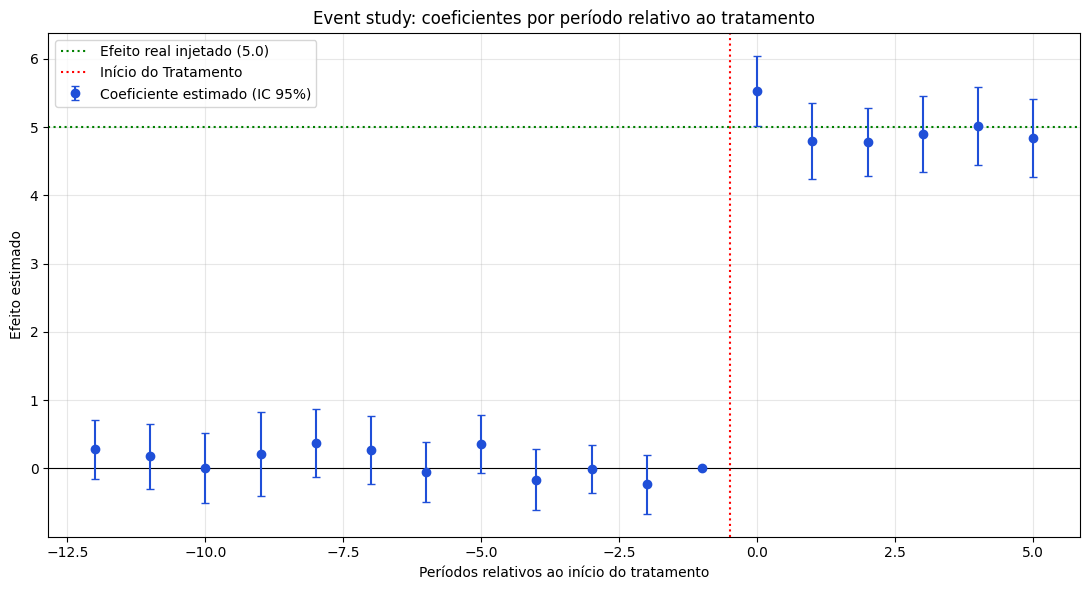

In [11]:
def plot_event_study(event_study, title, effect_line=None, effect_label=None):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.axhline(y=0, color='black', linewidth=0.8)
    if effect_line is not None:
        ax.axhline(y=effect_line, color='green', linestyle=':', linewidth=1.5, label=effect_label)
    ax.errorbar(
        event_study['rel_time'], event_study['coef'],
        yerr=1.96 * event_study['se'],
        fmt='o', color='#1f4fd8', ecolor='#1f4fd8', capsize=3, label='Coeficiente estimado (IC 95%)',
    )
    ax.axvline(x=-0.5, color='red', linestyle=':', linewidth=1.5, label='Início do Tratamento')
    ax.set_title(title)
    ax.set_xlabel('Períodos relativos ao início do tratamento')
    ax.set_ylabel('Efeito estimado')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_event_study(
    event_study,
    title='Event study: coeficientes por período relativo ao tratamento',
    effect_line=EFFECT_SIZE,
    effect_label=f'Efeito real injetado ({EFFECT_SIZE})',
)

## 9. Simplificações desta versão

- Um único momento de tratamento, o mesmo para todas as unidades tratadas ("adoção simultânea"). É o caso mais simples e mais fácil de interpretar.
- Erros-padrão clusterizados por unidade, sem correção adicional para poucos clusters (nesta simulação há 55 unidades, o suficiente para o cluster robusto se comportar bem; com poucas unidades — digamos, menos de ~30 clusters — seria o caso de considerar um *wild bootstrap*).
- Não há controles adicionais (covariáveis) na regressão — em um caso real, normalmente se inclui características que também variam no tempo e podem confundir a estimativa.

## 10. Bônus: o que acontece quando as tendências paralelas são violadas

Para deixar claro por que a checagem das seções 5 e 8 importa, geramos uma segunda versão dos dados em que o grupo tratado tem uma tendência própria, mais acentuada que a do controle, **desde antes do tratamento** — ou seja, quebramos a suposição de propósito. O efeito de tratamento injetado continua sendo o mesmo (`EFFECT_SIZE`), para comparar a estimativa nos dois cenários.

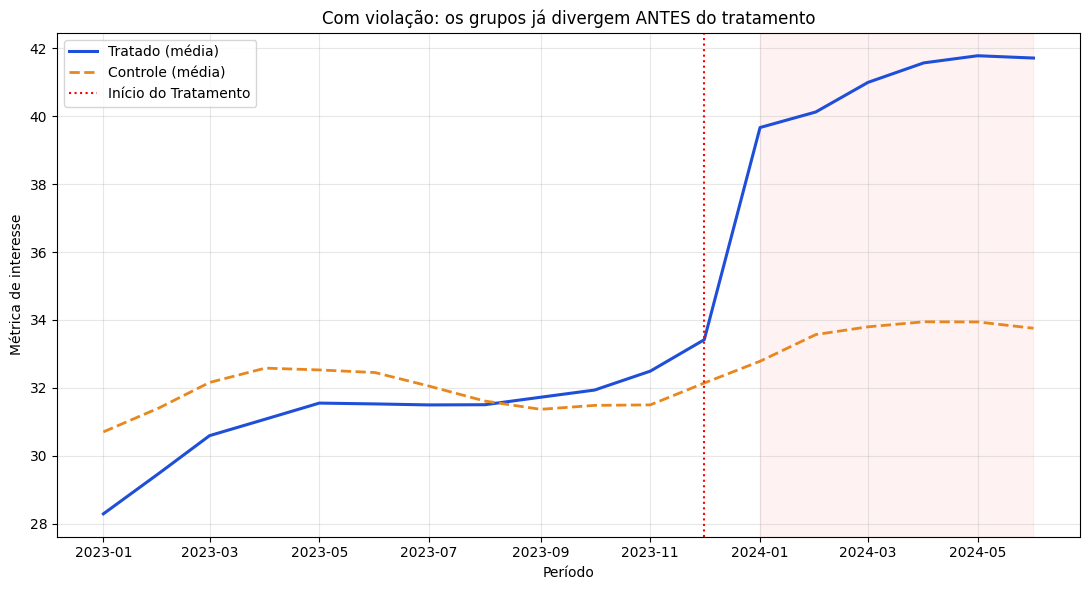

DiD estimado SEM violação (seção 7): 4.875  (efeito real: 5.0)
DiD estimado COM violação (esta seção): 7.913  (efeito real: 5.0)

Viés introduzido pela tendência divergente: +2.913


In [12]:
DIFFERENTIAL_TREND = 0.35  # tendência extra, só do grupo tratado, quebra o paralelismo de propósito


def generate_panel_with_violation(n_control, n_treated, n_total, common, differential_trend):
    t_arr = np.arange(n_total)
    records = []
    for group, n_units in [('control', n_control), ('treated', n_treated)]:
        extra_trend = differential_trend * t_arr if group == 'treated' else 0.0
        for u in range(n_units):
            unit_id = f'{group}_{u}'
            unit_fixed_effect = np.random.uniform(20, 40)
            idio_walk = np.cumsum(np.random.normal(0, 0.15, n_total))
            noise = np.random.normal(0, 0.5, n_total)
            y = unit_fixed_effect + common + extra_trend + idio_walk + noise
            for t in range(n_total):
                records.append({'unit_id': unit_id, 'group': group, 'time': t, 'y': y[t]})
    return pd.DataFrame(records)


df_viol = generate_panel_with_violation(n_control, n_treated, n_total, common, DIFFERENTIAL_TREND)
df_viol['treated_group'] = (df_viol['group'] == 'treated').astype(int)
df_viol['post_period'] = (df_viol['time'] >= n_pre).astype(int)
df_viol['date'] = df_viol['time'].map(dict(enumerate(dates)))
df_viol.loc[(df_viol['treated_group'] == 1) & (df_viol['post_period'] == 1), 'y'] += EFFECT_SIZE

avg_viol = df_viol.groupby(['date', 'group'])['y'].mean().unstack()

fig, ax = plt.subplots(figsize=(11, 6))
ax.axvspan(treatment_date, dates[-1], color='red', alpha=0.05, zorder=0)
ax.plot(avg_viol.index, avg_viol['treated'], label='Tratado (média)', color='#1f4fd8', linewidth=2.2)
ax.plot(avg_viol.index, avg_viol['control'], label='Controle (média)', color='#e8871e', linestyle='--', linewidth=2)
ax.axvline(x=dates[n_pre - 1], color='red', linestyle=':', linewidth=1.5, label='Início do Tratamento')
ax.set_title('Com violação: os grupos já divergem ANTES do tratamento')
ax.set_xlabel('Período')
ax.set_ylabel('Métrica de interesse')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

model_viol = smf.ols('y ~ treated_group * post_period', data=df_viol)
result_viol = model_viol.fit(cov_type='cluster', cov_kwds={'groups': df_viol['unit_id']})
coef_viol = result_viol.params['treated_group:post_period']

print(f"DiD estimado SEM violação (seção 7): {coef:.3f}  (efeito real: {EFFECT_SIZE})")
print(f"DiD estimado COM violação (esta seção): {coef_viol:.3f}  (efeito real: {EFFECT_SIZE})")
print(f"\nViés introduzido pela tendência divergente: {coef_viol - EFFECT_SIZE:+.3f}")

O gráfico acima mostra os dois grupos já se afastando antes da linha de início do tratamento. E a regressão confirma: o DiD estimado nesse cenário fica visivelmente distante do efeito real, porque parte do que a regressão atribui ao "tratamento" é, na verdade, a tendência que o grupo tratado já tinha antes — nada a ver com o tratamento em si. **Esse é o principal motivo pelo qual DiD não é "rodar uma regressão e pronto": a suposição de tendências paralelas precisa ser verificada, não assumida.**

Para fechar a comparação, rodamos o **mesmo event study da seção 8** (reaproveitando `build_event_study`/`plot_event_study`, sem duplicar lógica) neste cenário com violação. Se tendências paralelas valessem, os coeficientes pré-tratamento (`lead_*`) deveriam ficar perto de zero, como na seção 8; aqui, como o grupo tratado já tem uma tendência própria crescente desde antes do tratamento, esperamos ver esses coeficientes se afastando de zero de forma sistemática à medida que nos aproximamos do início do tratamento — é assim que o event study, na prática, ajudaria a *detectar* esse problema antes mesmo de rodar a regressão principal.

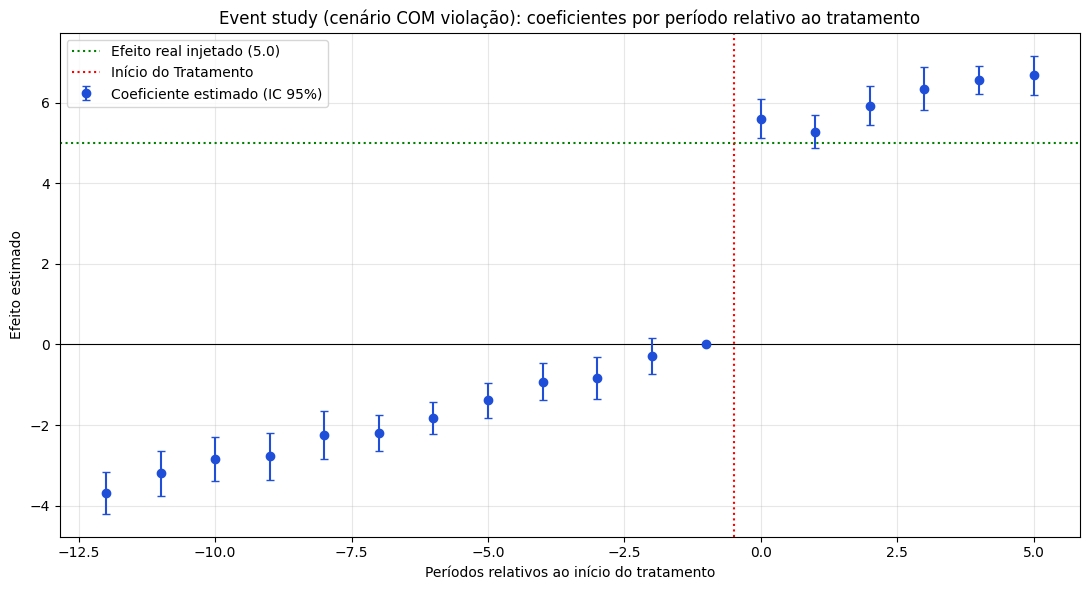

In [13]:
event_study_viol = build_event_study(df_viol, n_pre)
plot_event_study(
    event_study_viol,
    title='Event study (cenário COM violação): coeficientes por período relativo ao tratamento',
    effect_line=EFFECT_SIZE,
    effect_label=f'Efeito real injetado ({EFFECT_SIZE})',
)

## 11. Conclusão

Com tendências paralelas favorecidas por construção (seções 1 a 8), o DiD recuperou um efeito próximo do valor injetado, com erro-padrão clusterizado e intervalo de confiança contendo o valor real — a seção 7 validou isso explicitamente, comparando o efeito estimado com o valor verdadeiro conhecido. O gráfico da seção 5 tornou o contrafactual implícito na suposição de tendências paralelas visualmente explícito (a linha pontilhada é "o Tratado se nada tivesse acontecido") — vale lembrar que essa linha é uma representação visual, não algo estimado pela regressão. O event study deu evidência a favor da ausência de pré-tendência (coeficientes antes do tratamento perto de zero, salto no período de início) — evidência a favor da suposição, não uma prova de que ela vale. A seção 10 mostrou o outro lado, aplicando o mesmo event study a um cenário com violação: quando a suposição é violada, o mesmo procedimento de regressão gera uma estimativa visivelmente viesada, sem nenhum aviso na saída da regressão em si — mas o gráfico de tendências e o event study denunciam o problema, com os coeficientes pré-tratamento se afastando de zero de forma sistemática. E, tecnicamente, sob as hipóteses do método o que a regressão estima é o **ATT** (efeito sobre quem foi tratado) — nesta simulação ele coincide numericamente com o ATE porque o efeito foi injetado de forma homogênea, mas isso não se generaliza para dados reais com efeitos heterogêneos.

**Próximos passos, se for aplicar em dados reais:**

- **Verificar tendências paralelas de verdade** — com o máximo de períodos pré-tratamento disponíveis, tanto visualmente quanto com o event study da seção 8.
- **Cuidado com adoção escalonada** — se unidades diferentes são tratadas em momentos diferentes (não todas de uma vez, como aqui), o estimador de efeitos fixos bidirecionais (TWFE) usado nas seções 7 e 8 pode ficar viesado, porque acaba usando unidades já tratadas como "controle" implícito para outras. A literatura recente (Goodman-Bacon, 2021; Callaway & Sant'Anna, 2021; de Chaisemartin & D'Haultfœuille) propõe estimadores robustos a esse problema — vale a pena migrar para eles antes de confiar em TWFE com tratamento escalonado.
- **Erros-padrão com poucos clusters** — com poucas unidades por grupo (dezenas, não centenas), o cluster robusto padrão pode ficar anticonservador; um *wild cluster bootstrap* é a alternativa recomendada.

**Referências usadas na pesquisa para este notebook:**

- [Huntington-Klein, N. — *The Effect*, capítulo sobre Diferenças-em-Diferenças](https://www.theeffectbook.net/ch-DifferenceinDifference.html)
- [Columbia University Mailman School of Public Health — Difference-in-Difference Estimation](https://www.publichealth.columbia.edu/research/population-health-methods/difference-difference-estimation)
- [Carlos Mendez — Introduction to Difference-in-Differences in Python](https://carlos-mendez.org/post/python_did/)
- [Sant'Anna, P. H. C. — Difference-in-Differences Methods: A brief overview](https://pdhp.isr.umich.edu/wp-content/uploads/2023/01/DiD_PDHP.pdf)
- [Goodman-Bacon, A. (2021) — Difference-in-differences with variation in treatment timing](https://www.sciencedirect.com/science/article/abs/pii/S0304407620303948)